In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [61]:
!pip install ucimlrepo

# 1. Load Data

In [132]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
chronic_kidney_disease = fetch_ucirepo ( id =336)
# data ( as pandas dataframes )
X = chronic_kidney_disease . data . features
y = chronic_kidney_disease . data . targets
Data = pd.concat([ X , y ], axis =1)
Data

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bp'}>,
        <Axes: title={'center': 'sg'}>, <Axes: title={'center': 'al'}>],
       [<Axes: title={'center': 'su'}>, <Axes: title={'center': 'bgr'}>,
        <Axes: title={'center': 'bu'}>, <Axes: title={'center': 'sc'}>],
       [<Axes: title={'center': 'sod'}>, <Axes: title={'center': 'pot'}>,
        <Axes: title={'center': 'hemo'}>,
        <Axes: title={'center': 'pcv'}>],
       [<Axes: title={'center': 'wbcc'}>,
        <Axes: title={'center': 'rbcc'}>, <Axes: >, <Axes: >]],
      dtype=object)

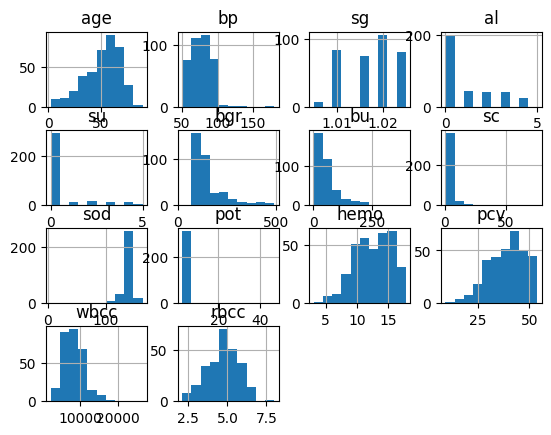

In [63]:
Data.hist()

# 2. Correlation

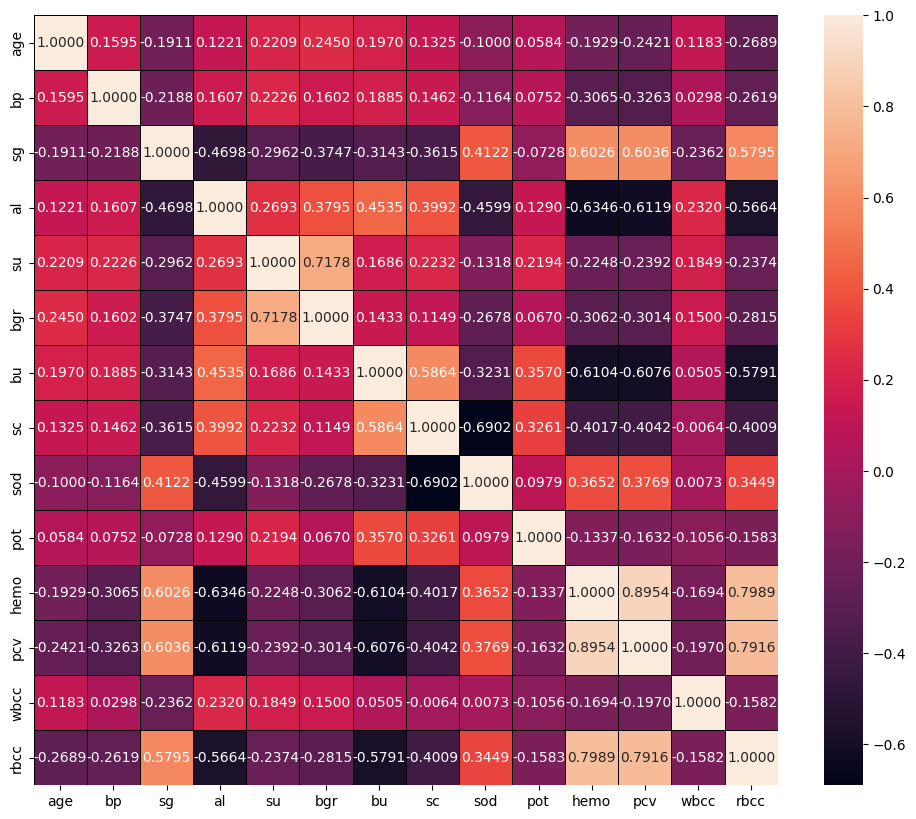

In [64]:
# kode ini mengambil data numerik, menghitung korelasinya, dan kemudian menampilkan korelasi tersebut dalam bentuk heatmap
# Heatmap ini membantu kita untuk dapat dengan cepat melihat variabel mana yang memiliki korelasi kuat dan arah korelasinya (positif atau negatif).

numeric_data = Data.select_dtypes(include=['number'])
f, ax = plt.subplots(figsize = (12,10))
sns.heatmap(numeric_data.corr(), annot = True, linewidths=0.5,
            linecolor = "black", fmt = ".4f", ax = ax)
plt.show()

In [65]:
sns.pairplot(Data, hue='class')

Output hidden; open in https://colab.research.google.com to view.

In [66]:
Data.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


# 3. NaN and Duplicate Identification

In [67]:
Data_raw = Data
Data.info()       # untuk melihat info tipe data tiap kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [68]:
Data_raw.isna().sum()     # info jumlah Nan tiap kolom data

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


In [69]:
Data_raw.duplicated().sum()

np.int64(0)

In [70]:
!pip install missingno

1. MCAR (Missing Completely At Random):
Data hilang secara acak tanpa pola, seperti kelereng yang terlepas dari kantong secara tiba-tiba tanpa alasan tertentu.

2. MAR (Missing At Random):
Data hilang karena dipengaruhi oleh informasi lain yang diketahui, seperti ketika seseorang lupa membawa buku pelajaran karena sedang terburu-buru—kita bisa menduga keterburuannya sebagai penyebabnya.

3. MNAR (Missing Not At Random):
Data hilang karena alasan yang berkaitan langsung dengan nilai itu sendiri, seperti seseorang sengaja menyembunyikan rahasianya karena merasa informasi itu terlalu pribadi.

<Axes: >

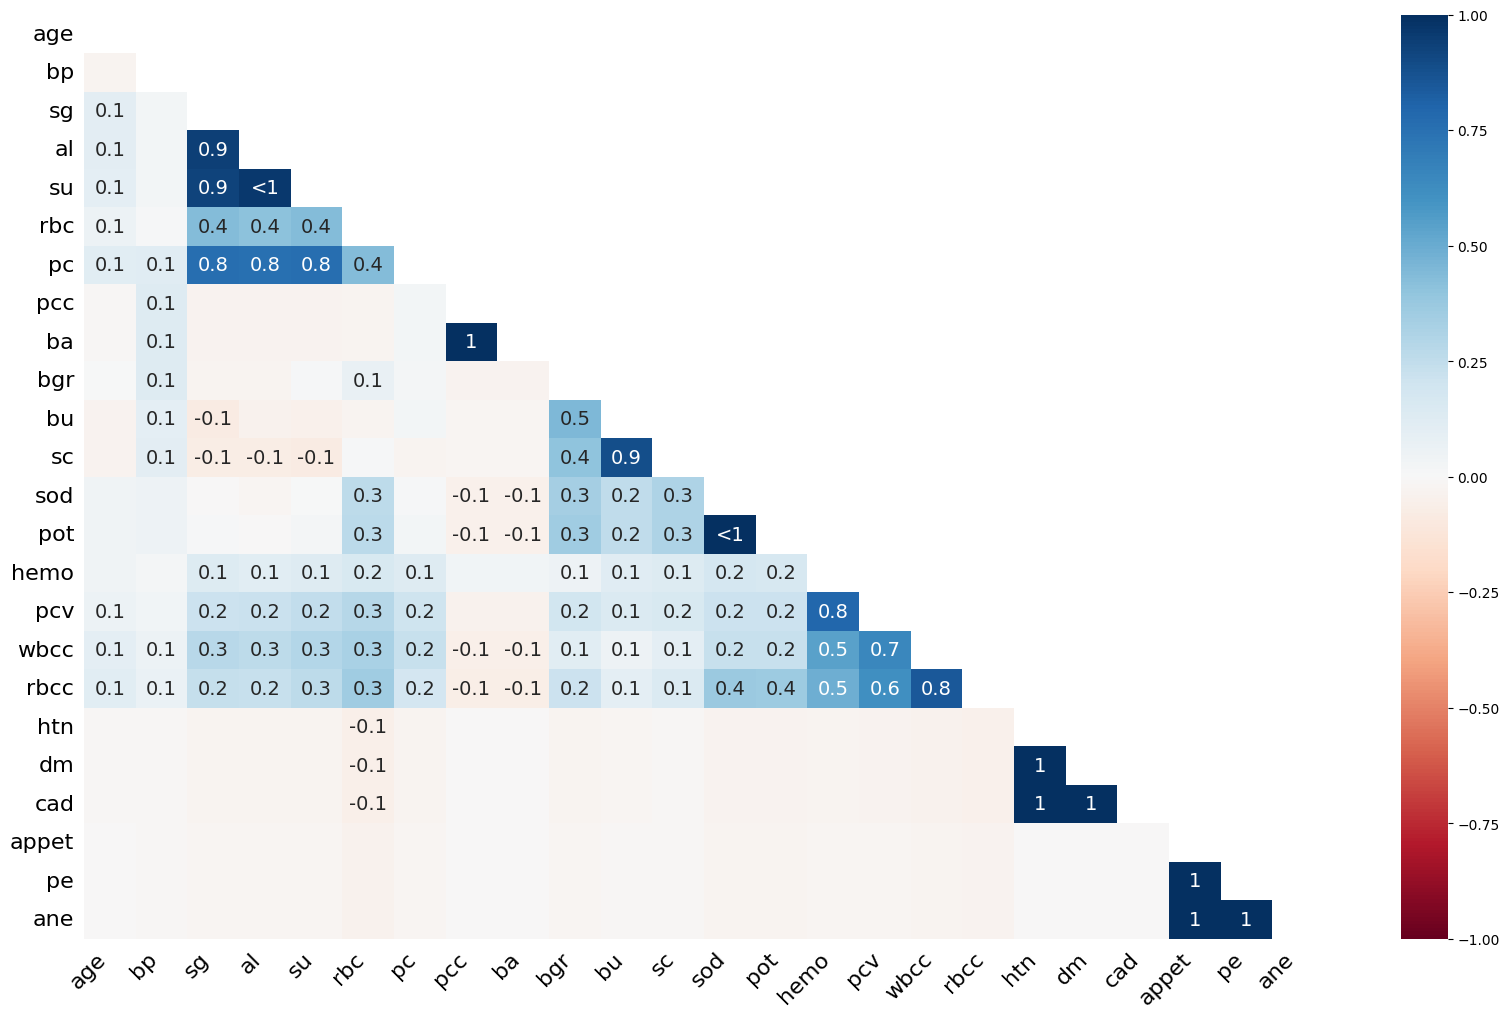

In [71]:
import missingno as msno

msno.heatmap(Data)

## Handling NaN by Embun

### Distribusi Fitur Numerik

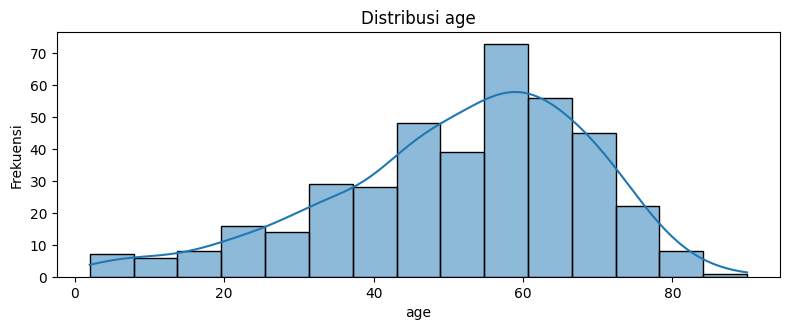

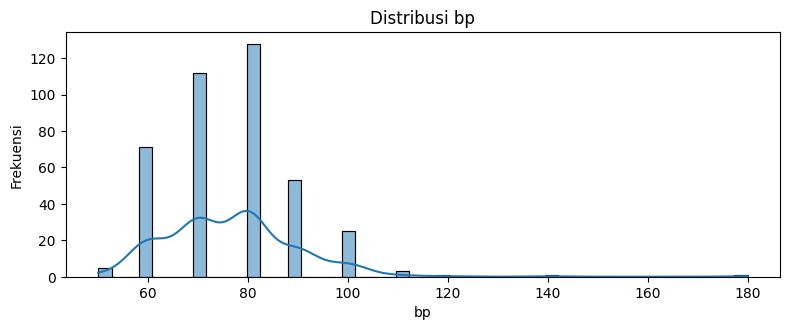

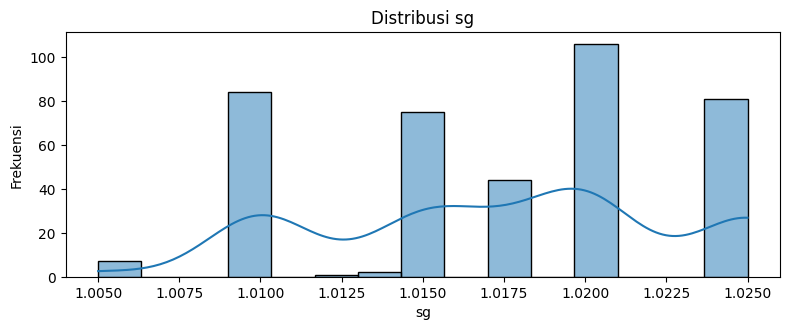

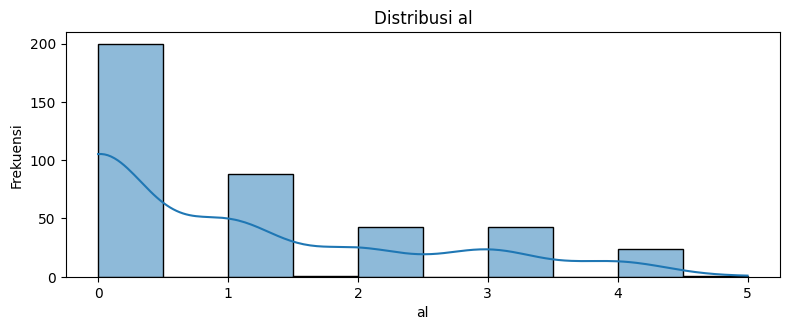

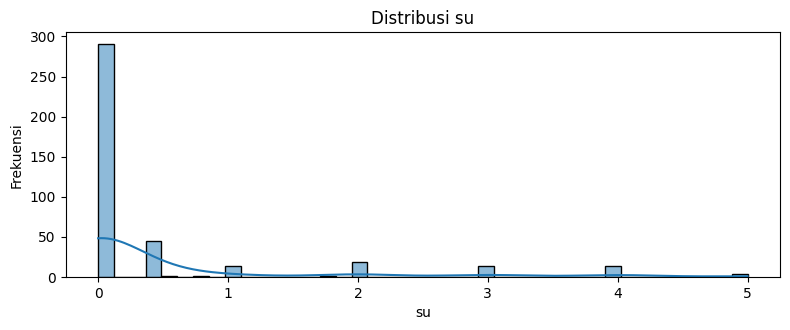

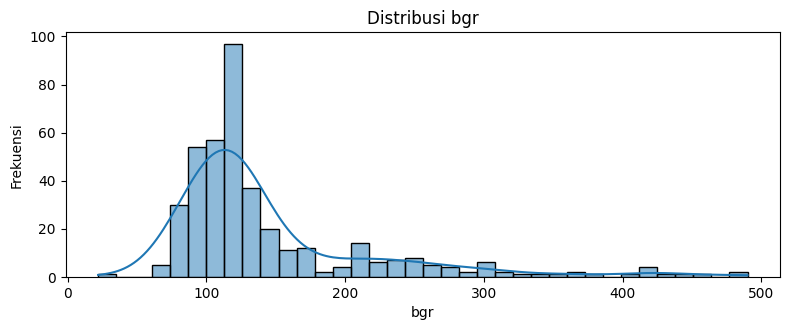

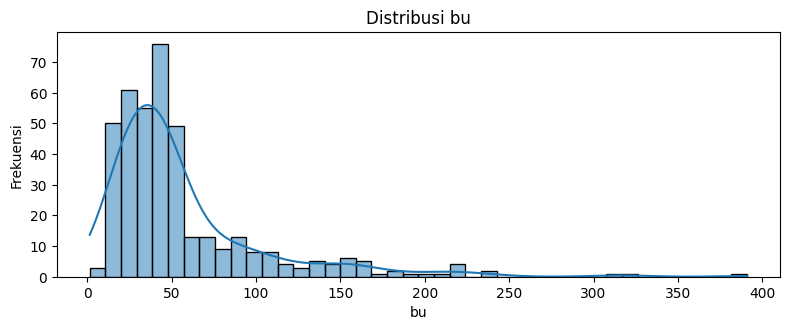

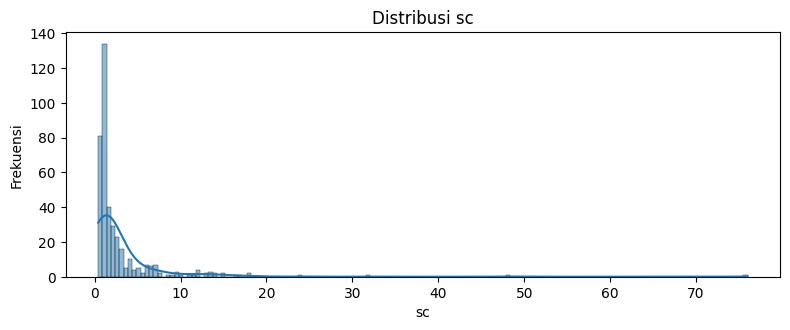

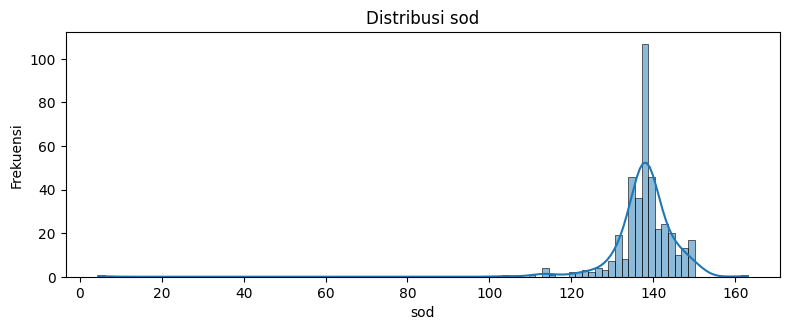

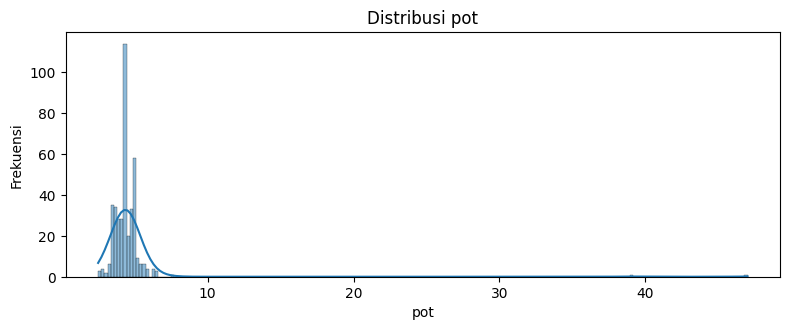

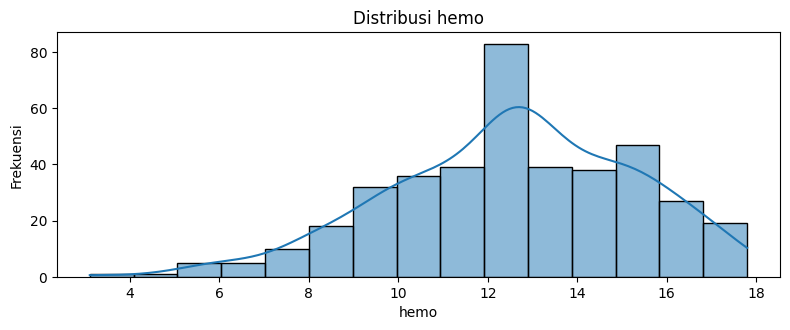

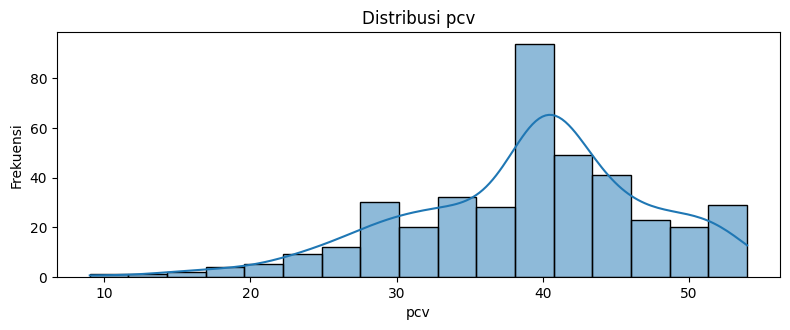

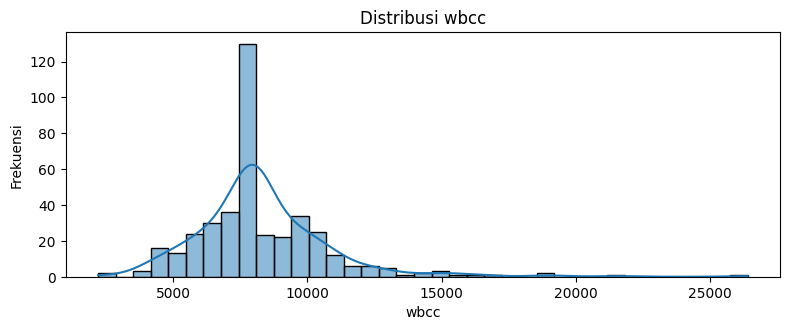

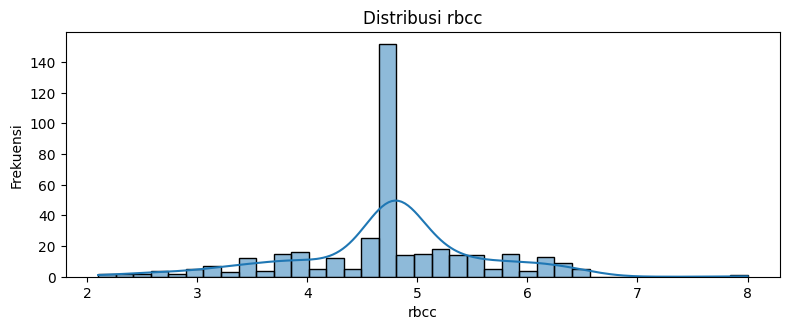

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,1
pc,2
pcc,0
ba,0
bgr,0


In [101]:
def distribusi(data):
  Data = data
  numeric_data = Data.select_dtypes(include=['number'])

  # Buat histogram dan boxplot untuk setiap kolom numerik
  for column in numeric_data.columns:
    plt.figure(figsize=(8, 6))

    # Buat histogram
    plt.subplot(2, 1, 1)
    sns.histplot(data=Data, x=column, kde=True)
    plt.title(f'Distribusi {column}')
    plt.xlabel(column)
    plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()
  return

distribusi(Data)

In [133]:
# Cek jumlah NaN untuk memastikan yang numerik NaNnya masih sama
Data.isna().sum()

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


### Handling with SimpleImputer: Median

In [134]:
# Salin data
DataClean_Median = Data.copy()

# Imputasi numerik dengan median
imputer = SimpleImputer(strategy='median')
DataClean_Median[['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']] = imputer.fit_transform(DataClean_Median[['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']])




In [ ]:
# Cek distribusi setelah imputed median
distribusi(DataClean_Median)

# Dapat dilihat bahwa hasilnya tidak mengubah bentuk distribusi data setiap kolomnya

In [135]:
# Cek jumlah NaN
DataClean_Median.isna().sum()

,0
age,0
bp,0
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,0


### Handling with KNNImputer

In [136]:
# Handle missing value dgn KNNImputer
from sklearn.impute import KNNImputer

# Salin data
DataClean_KNN = DataClean_Median.copy()

# Terapkan imputasi pada kolom age
imputer = KNNImputer(n_neighbors=5)
DataClean_KNN[['sg', 'al', 'su']] = imputer.fit_transform(DataClean_KNN[['sg', 'al', 'su']])


In [ ]:
# Cek distribusi setelah imputed KNN
distribusi(DataClean_KNN)

In [137]:
# Cek jumlah NaN
DataClean_KNN.isna().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,152
pc,65
pcc,4
ba,4
bgr,0


### Handling NaN Tipe Data Objek/Kategorikal

In [138]:
# Cek data
DataClean_KNN

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [144]:
# untuk rbc
# diisi abnormal jika class "ckd", sesuai deskripsi pada modul bahwa jika rbc abnormal maka mengindikasikan ginjalnya rusak
DataClean_KNN['rbc'] = DataClean_KNN.apply(
        lambda row: 'abnormal' if pd.isna(row['rbc']) and row['class'] == 'ckd'
        else 'normal' if pd.isna(row['rbc']) and row['class'] == 'notckd'
        else row['rbc'],
        axis=1)

# Cek jumlah NaN
DataClean_KNN.isna().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,1
pc,65
pcc,4
ba,4
bgr,0


In [145]:
# untuk pc
# diisi abnormal jika class "ckd", sesuai deskripsi pada modul bahwa jika pc abnormal maka mengindikasikan radang ginjal
DataClean_KNN['pc'] = DataClean_KNN.apply(
        lambda row: 'abnormal' if pd.isna(row['pc']) and row['class'] == 'ckd'
        else 'normal' if pd.isna(row['pc']) and row['class'] == 'notckd'
        else row['pc'],
        axis=1)

# Cek jumlah NaN
DataClean_KNN.isna().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,1
pc,1
pcc,4
ba,4
bgr,0


In [149]:
# Sisanya bisa kita drop saja karena hanya sedikit jumlahnya
DataClean = DataClean_KNN.dropna()

# Cek Jumlah NaN Data Clean
DataClean.isna().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


In [157]:
# Print Data Clean
DataClean

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,abnormal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,abnormal,normal,notpresent,notpresent,121.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


# 4. Checking Typografi Categorical Data or Nominal Data Type

In [158]:
# Copy Data
Data_clean_fix = DataClean

# Cek Typografi biar keliatan ada yang belum sesuai apa ga
object_data = Data_clean_fix.select_dtypes(include=['object'])
for i in range(len(object_data.columns)):
  cols = object_data.columns
  print(f'{object_data[cols[i]]} = memiliki atribut {object_data[cols[i]].unique()}')

0      abnormal
1      abnormal
2        normal
3        normal
4        normal
         ...   
395      normal
396      normal
397      normal
398      normal
399      normal
Name: rbc, Length: 392, dtype: object = memiliki atribut ['abnormal' 'normal']
0        normal
1        normal
2        normal
3      abnormal
4        normal
         ...   
395      normal
396      normal
397      normal
398      normal
399      normal
Name: pc, Length: 392, dtype: object = memiliki atribut ['normal' 'abnormal']
0      notpresent
1      notpresent
2      notpresent
3         present
4      notpresent
          ...    
395    notpresent
396    notpresent
397    notpresent
398    notpresent
399    notpresent
Name: pcc, Length: 392, dtype: object = memiliki atribut ['notpresent' 'present']
0      notpresent
1      notpresent
2      notpresent
3      notpresent
4      notpresent
          ...    
395    notpresent
396    notpresent
397    notpresent
398    notpresent
399    notpresent
Name: ba, Len

In [161]:
# Ternyata di 'dm' dan 'class' ada yang dikotori dengan spasi '\t', maka perlu dibersihkan

# Betulin class
class_obj = []
# Use .iterrows() to iterate through rows and index
for index, row in Data_clean_fix.iterrows():
  if row['class'] == 'ckd\t':
    class_obj.append('ckd')
  elif row['class'] == 'notckd':
    class_obj.append('notckd')
  elif row['class'] == 'ckd':
    class_obj.append('ckd')
Data_clean_fix['class'] = class_obj

# Betulin dm
dm_obj = []
# Use .iterrows() to iterate through rows and index
for index, row in Data_clean_fix.iterrows():
  if row['dm'] == '\tno':
    dm_obj.append('no')
  elif row['dm'] == 'no':
    dm_obj.append('no')
  elif row['dm'] == 'yes':
    dm_obj.append('yes')

<ipython-input-161-de0f11fbb567>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_clean_fix['class'] = class_obj


# 5. Outlier Detection

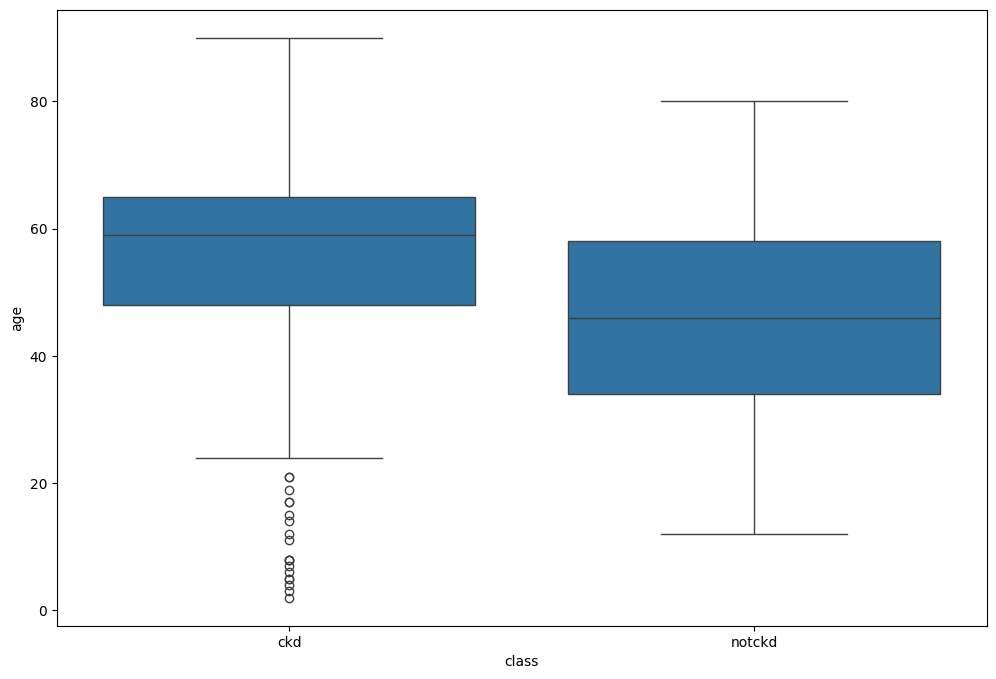

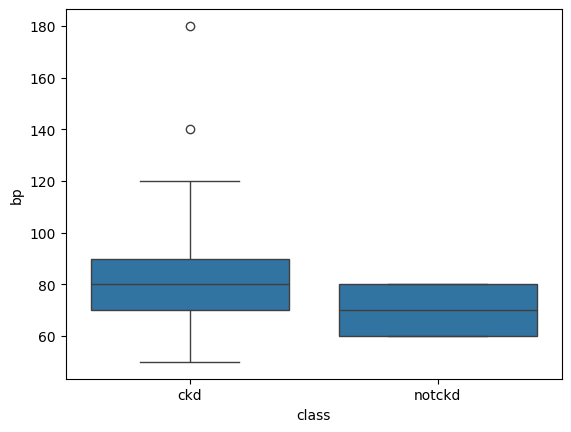

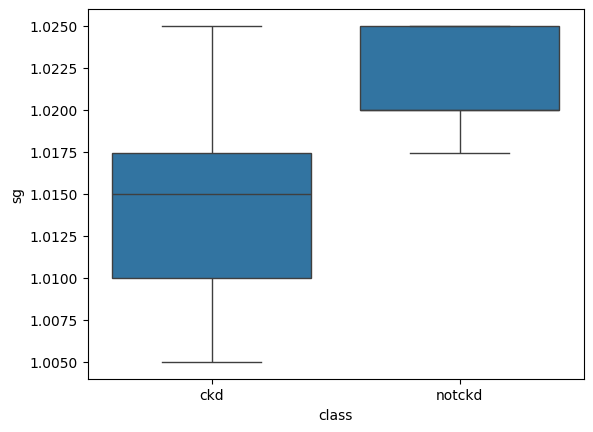

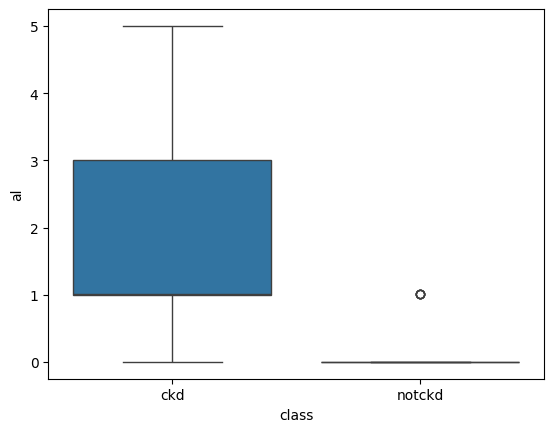

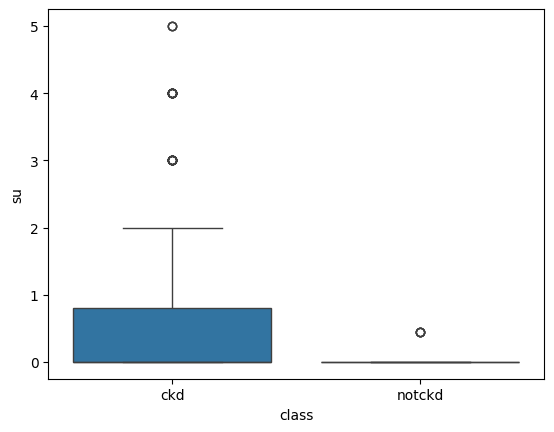

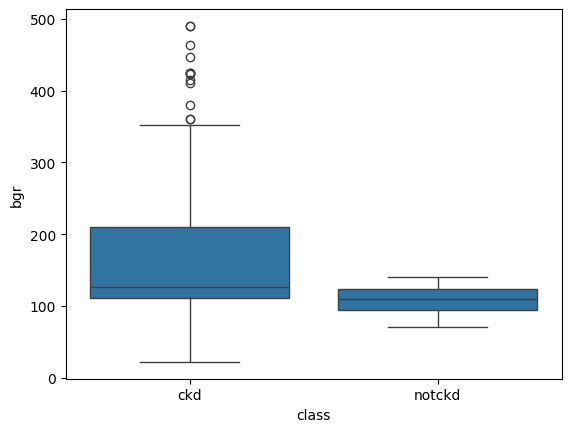

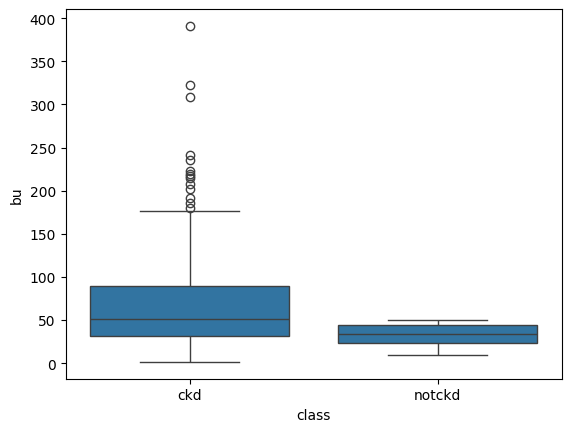

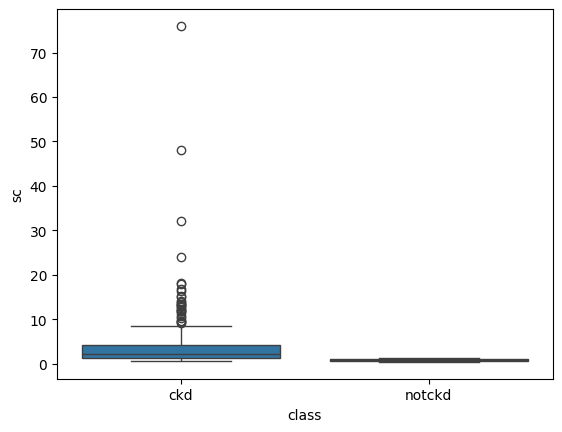

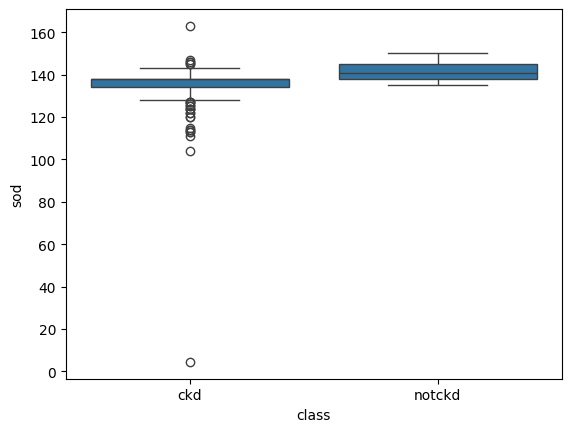

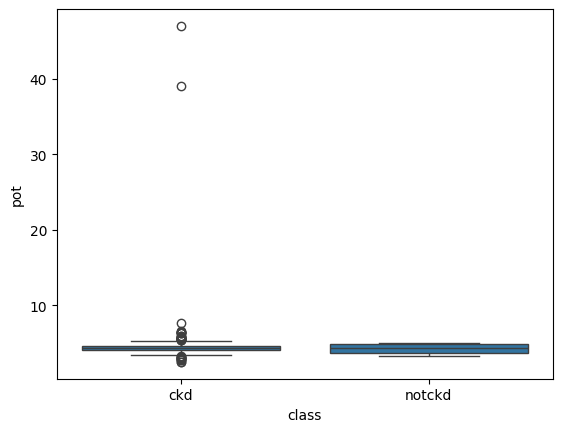

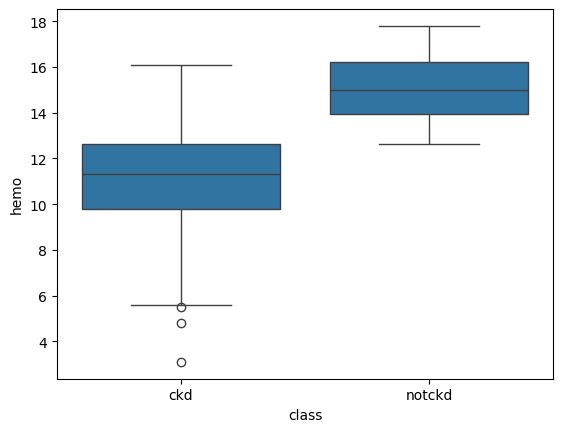

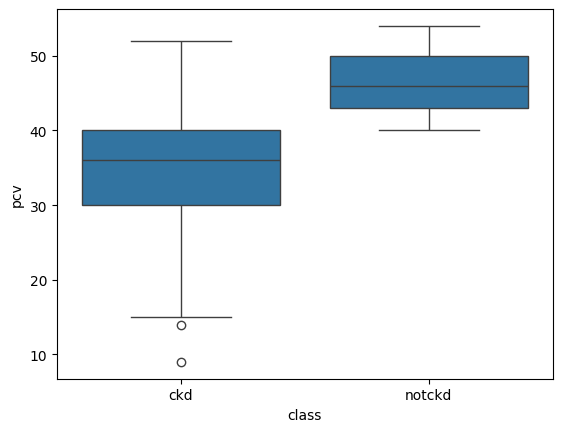

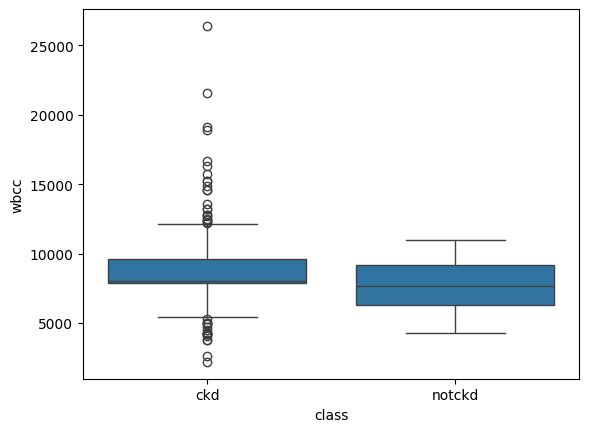

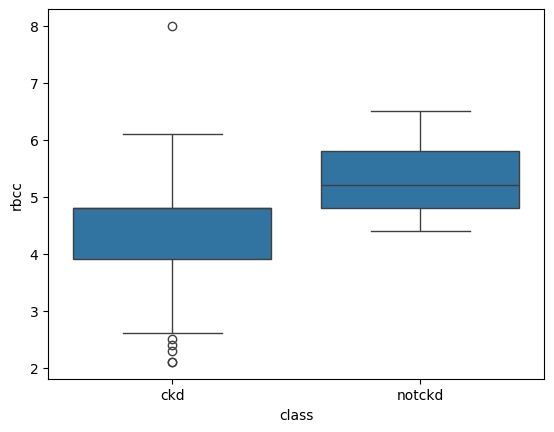

In [162]:
plt.figure(figsize=(12, 8))
numeric_data_clean = Data_clean_fix.select_dtypes(include='number')
for i in range(len(numeric_data_clean.columns)):
  sns.boxplot(x = 'class', y = numeric_data_clean.columns[i], data = Data_clean_fix)
  plt.show()

## 5.1. IQR (Inter Quartile Range)

Boxplot_vs_PDF.svg

In [163]:
def remove_outliers_with_IQR(df, target_col):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    def filter_group(group):
        mask = pd.Series(True, index=group.index)
        for col in numeric_cols:
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            mask &= (group[col] >= lower_bound) & (group[col] <= upper_bound)
        return group[mask]

    df_clean = df.groupby(target_col, group_keys=False).apply(filter_group)
    return df_clean.reset_index(drop=True)

In [164]:
clean_data = remove_outliers_with_IQR(Data_clean_fix, 'class')
clean_data

<ipython-input-163-1df5efde18fa>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby(target_col, group_keys=False).apply(filter_group)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020000,1.000000,0.000000,abnormal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,51.0,80.0,1.010000,2.000000,0.000000,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
2,52.0,100.0,1.015000,3.000000,0.000000,normal,abnormal,present,notpresent,138.0,...,33.0,9600.0,4.0,yes,yes,no,good,no,yes,ckd
3,68.0,70.0,1.017408,1.016949,0.450142,abnormal,abnormal,notpresent,notpresent,98.0,...,40.0,8000.0,4.8,yes,yes,yes,poor,yes,no,ckd
4,47.0,70.0,1.015000,2.000000,0.000000,abnormal,normal,notpresent,notpresent,99.0,...,40.0,8000.0,4.8,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,55.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
256,42.0,70.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
257,12.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
258,17.0,60.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


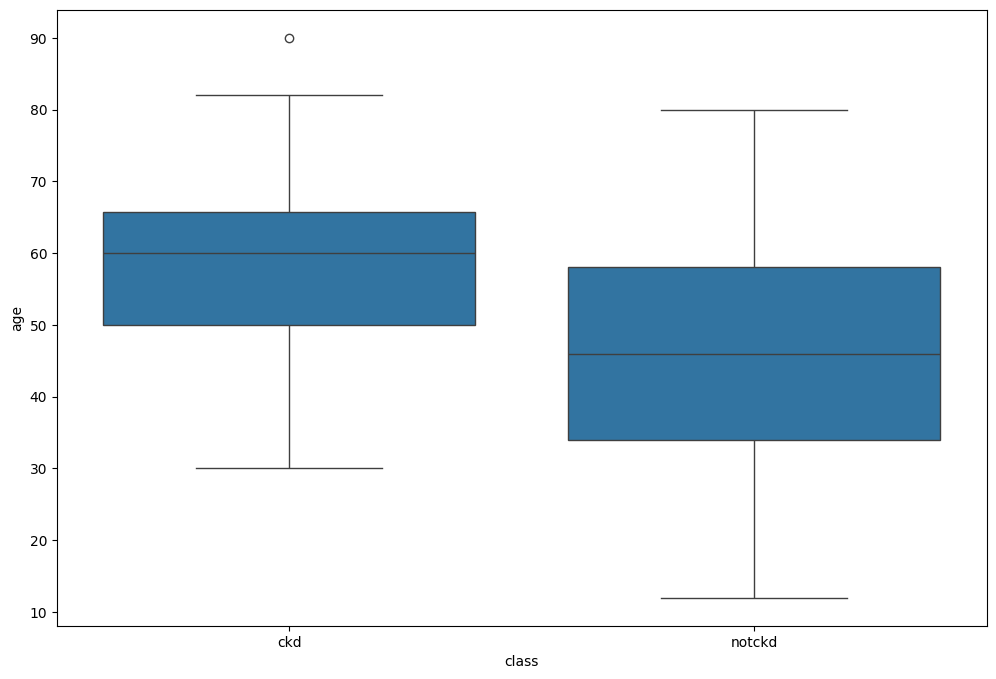

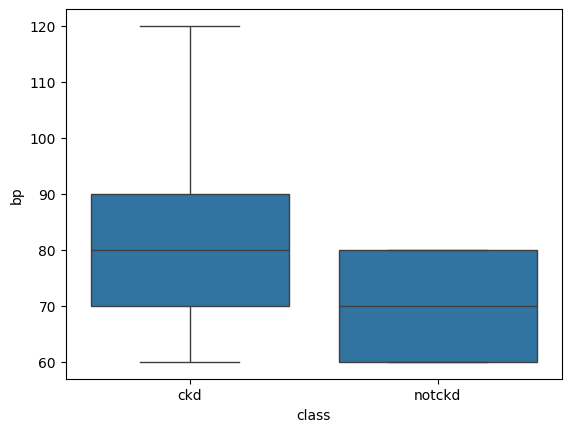

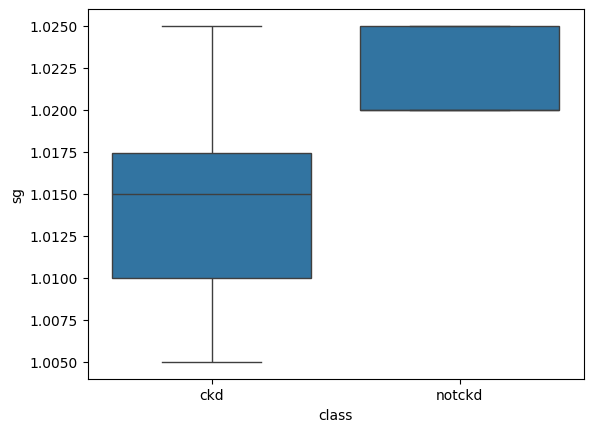

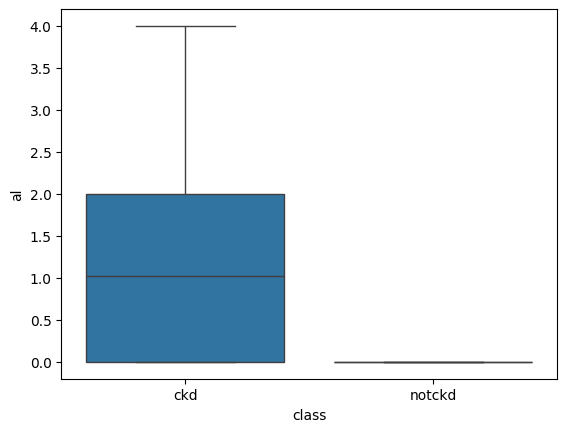

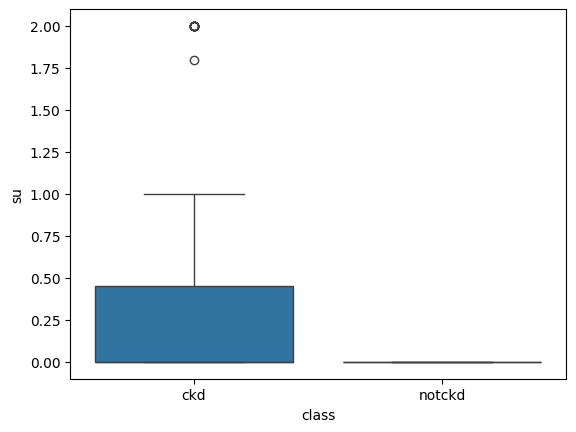

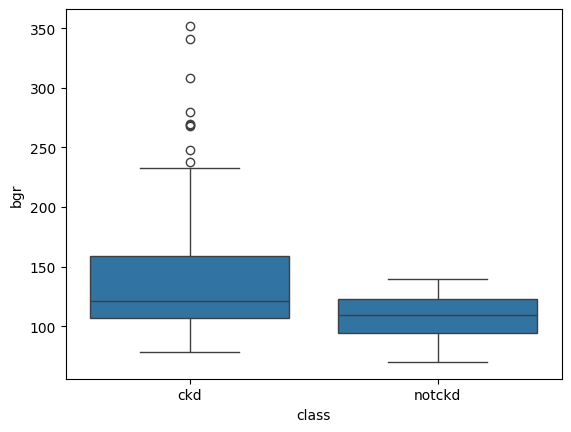

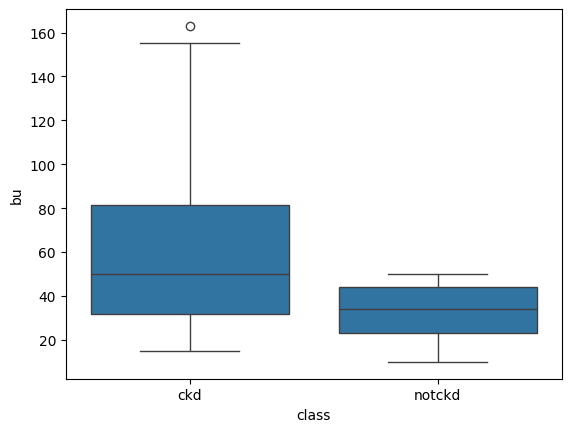

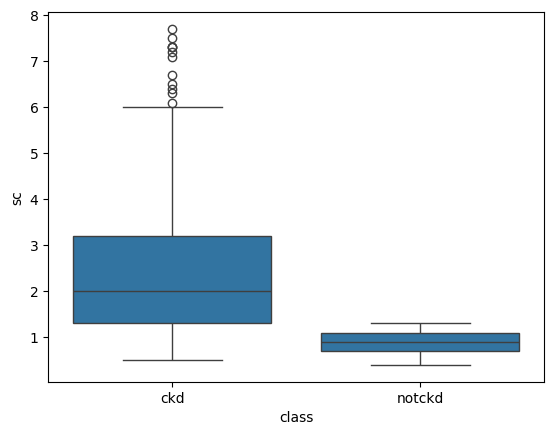

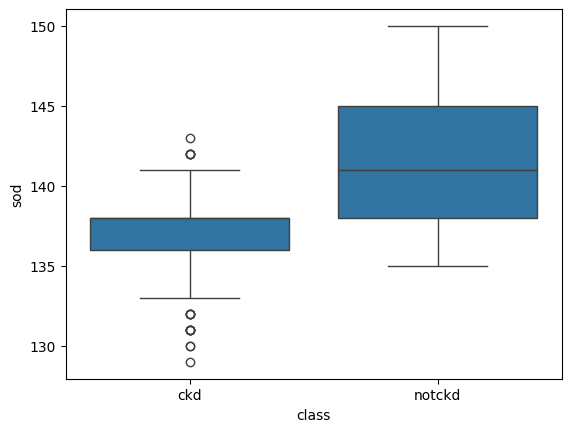

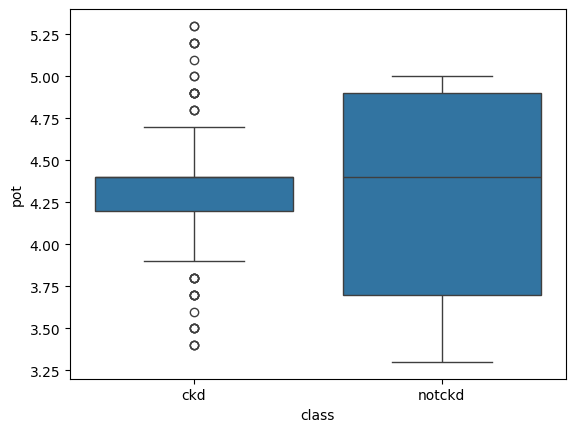

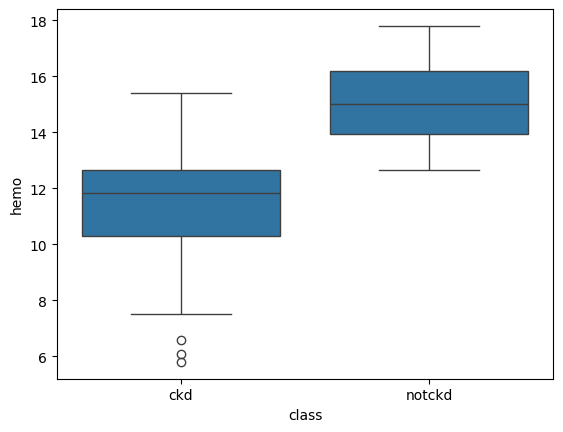

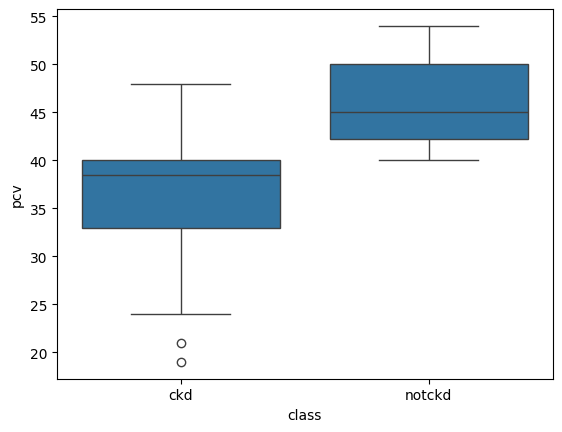

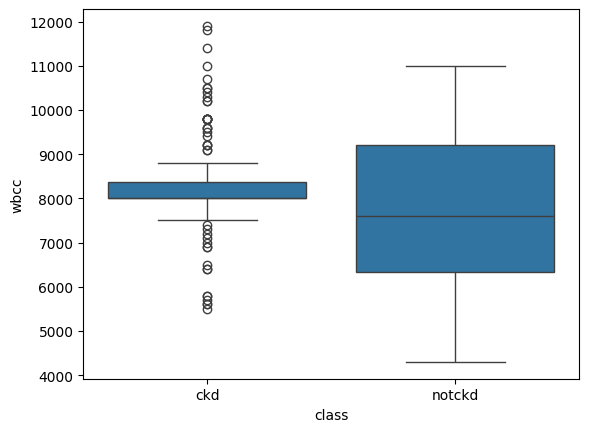

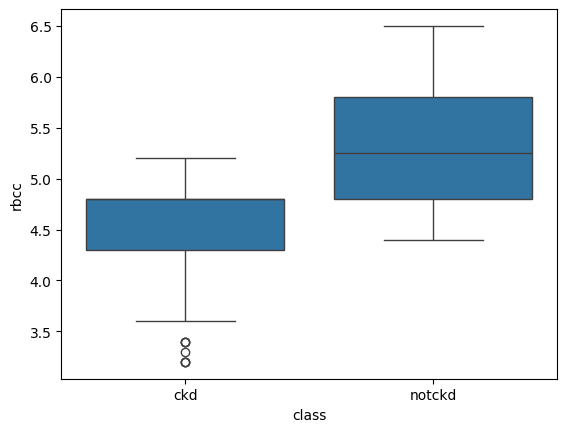

In [165]:
plt.figure(figsize=(12, 8))
numeric_data_clean = clean_data.select_dtypes(include='number')
for i in range(len(numeric_data_clean.columns)):
  sns.boxplot(x = 'class', y = numeric_data_clean.columns[i], data = clean_data)
  plt.show()

# 6. Similarity/Disimilarity

In [167]:
Similarity_Data_Sample = clean_data
Similarity_Data_Sample

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020000,1.000000,0.000000,abnormal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,51.0,80.0,1.010000,2.000000,0.000000,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
2,52.0,100.0,1.015000,3.000000,0.000000,normal,abnormal,present,notpresent,138.0,...,33.0,9600.0,4.0,yes,yes,no,good,no,yes,ckd
3,68.0,70.0,1.017408,1.016949,0.450142,abnormal,abnormal,notpresent,notpresent,98.0,...,40.0,8000.0,4.8,yes,yes,yes,poor,yes,no,ckd
4,47.0,70.0,1.015000,2.000000,0.000000,abnormal,normal,notpresent,notpresent,99.0,...,40.0,8000.0,4.8,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,55.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
256,42.0,70.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
257,12.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
258,17.0,60.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


## 6.1 Numerical Distance

In [168]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def standardize_numerical(df, num_cols):
    df_std = df.copy()
    scaler = StandardScaler()
    df_std[num_cols] = scaler.fit_transform(df[num_cols])
    return df_std

def numerical_distance(df, num_cols, metric='euclidean', p=3, normalize_result=True):
    df_std = standardize_numerical(df, num_cols)
    X = df_std[num_cols].to_numpy(dtype=float)

    if metric == 'euclidean':
        d = cdist(X, X, metric='euclidean')
    elif metric == 'minkowski':
        d = cdist(X, X, metric='minkowski', p=p)
    elif metric == 'cosine':
        d = cdist(X, X, metric='cosine')
    elif metric == 'mahalanobis':
        cov = np.cov(X, rowvar=False)
        try:
            inv_cov = np.linalg.inv(cov)
        except np.linalg.LinAlgError:
            inv_cov = np.linalg.pinv(cov)
        d = cdist(X, X, metric='mahalanobis', VI=inv_cov)
    else:
        raise ValueError("Unsupported numerical metric.")

    if normalize_result == True:
      max_d = d.max()
      d_norm = d / max_d if max_d > 0 else d
      result = d_norm
    else:
      result = d
    return result

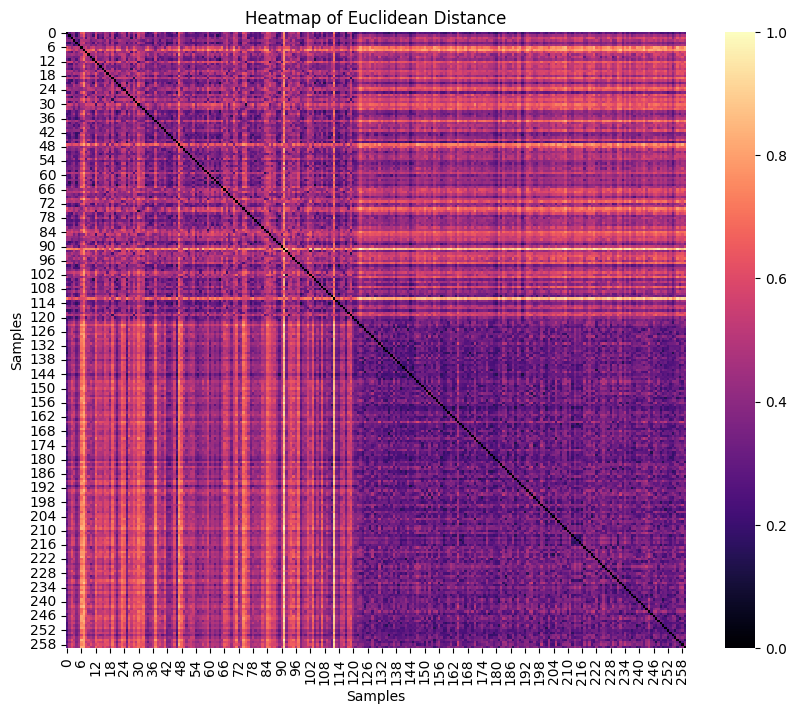

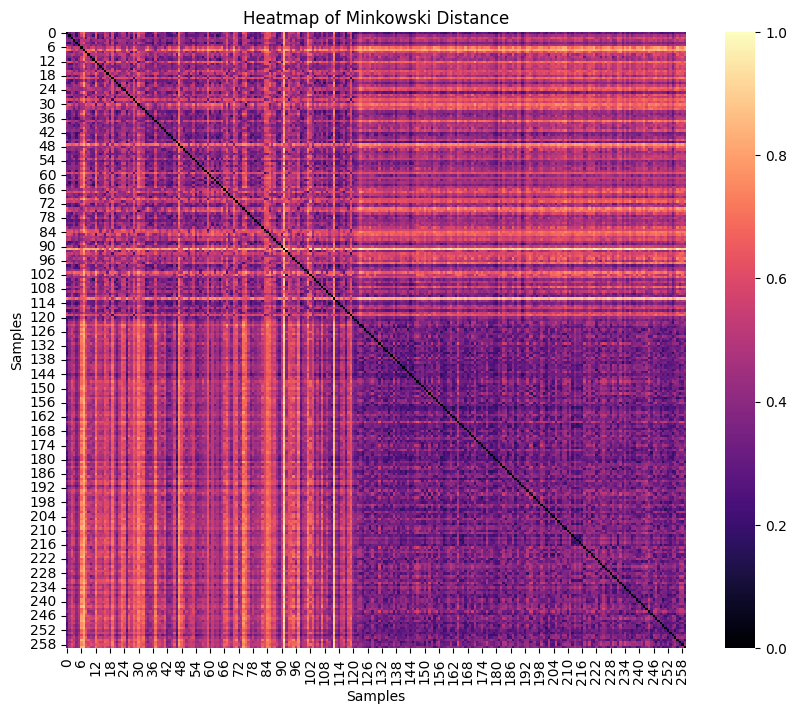

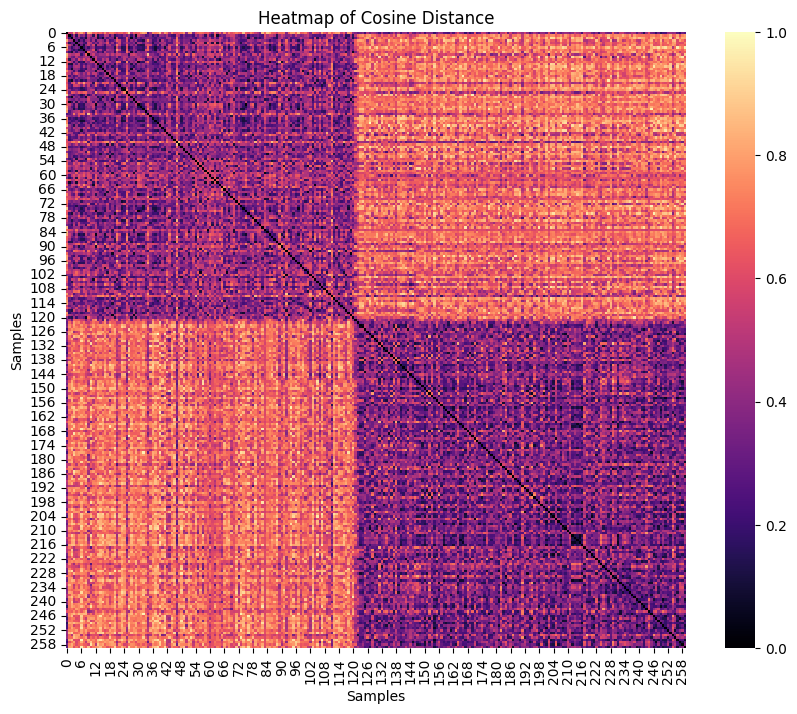

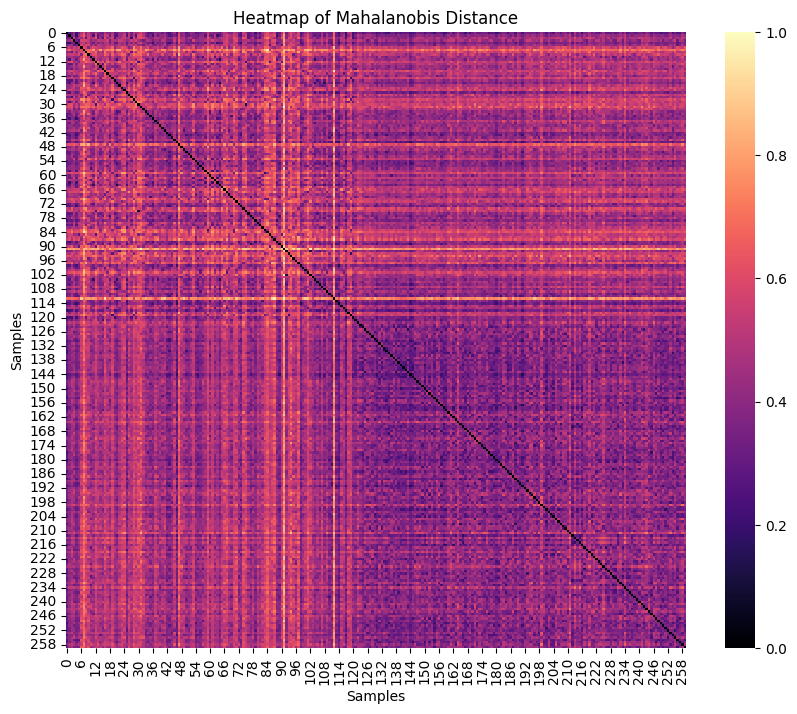

In [169]:
Similarity_data_numerical = Similarity_Data_Sample.select_dtypes(include=['number']).columns

metrics = ['euclidean', 'minkowski', 'cosine', 'mahalanobis']

for metric in metrics:
    dist_matrix = numerical_distance(Similarity_Data_Sample, Similarity_data_numerical, metric=metric, normalize_result=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(dist_matrix, cmap='magma', annot=False)
    plt.title(f"Heatmap of {metric.capitalize()} Distance")
    plt.xlabel("Samples")
    plt.ylabel("Samples")
    plt.show()

## 6.2 Categorical Distance

In [170]:
def jaccard_dist(df, nom_cols):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    nominal_data = encoder.fit_transform(df[nom_cols])
    nominal_bool = nominal_data.astype(bool)
    d = cdist(nominal_bool, nominal_bool, metric='jaccard')
    return d

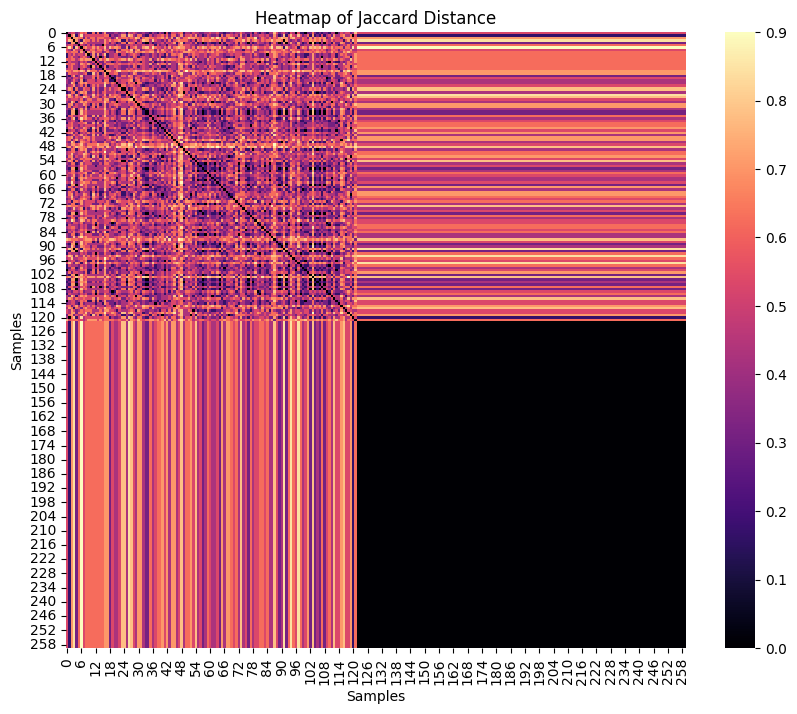

In [171]:
Similarity_data_categorical = Similarity_Data_Sample.select_dtypes(include=['object']).columns

jaccard_matrix = jaccard_dist(Similarity_Data_Sample, Similarity_data_categorical)

plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_matrix, cmap='magma', annot=False)
plt.title("Heatmap of Jaccard Distance")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()

## 6.3 Combine Distance (Gower's Distance)

https://github.com/wwwjk366/gower/tree/master

In [172]:
!pip install gower

In [173]:
Similarity_Data_Sample

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020000,1.000000,0.000000,abnormal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,51.0,80.0,1.010000,2.000000,0.000000,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
2,52.0,100.0,1.015000,3.000000,0.000000,normal,abnormal,present,notpresent,138.0,...,33.0,9600.0,4.0,yes,yes,no,good,no,yes,ckd
3,68.0,70.0,1.017408,1.016949,0.450142,abnormal,abnormal,notpresent,notpresent,98.0,...,40.0,8000.0,4.8,yes,yes,yes,poor,yes,no,ckd
4,47.0,70.0,1.015000,2.000000,0.000000,abnormal,normal,notpresent,notpresent,99.0,...,40.0,8000.0,4.8,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,55.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
256,42.0,70.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
257,12.0,80.0,1.020000,0.000000,0.000000,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
258,17.0,60.0,1.025000,0.000000,0.000000,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


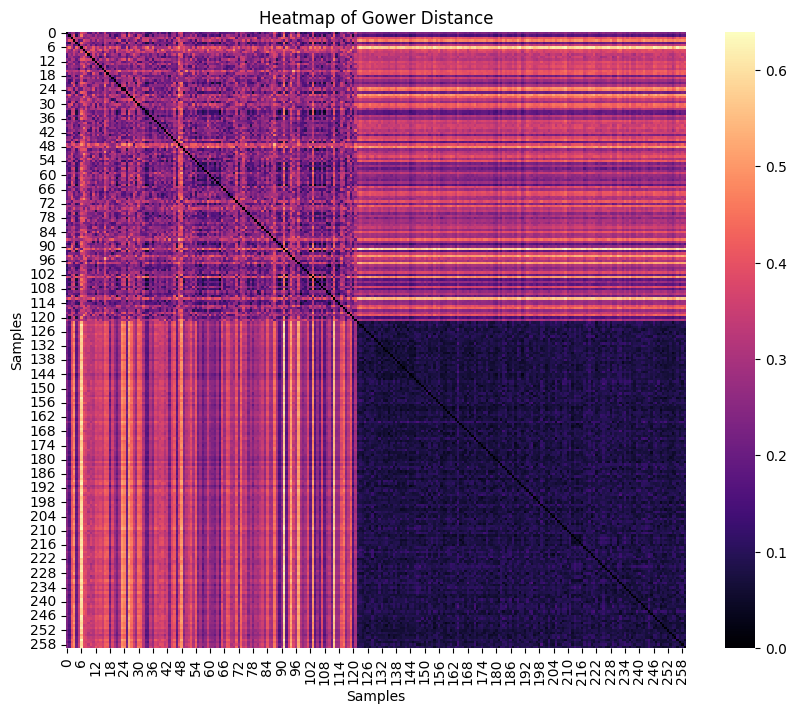

In [174]:
import gower

gower_dist = gower.gower_matrix(Similarity_Data_Sample)

plt.figure(figsize=(10, 8))
sns.heatmap(gower_dist, cmap='magma', annot=False)
plt.title("Heatmap of Gower Distance")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()

## 6.4 Correlation

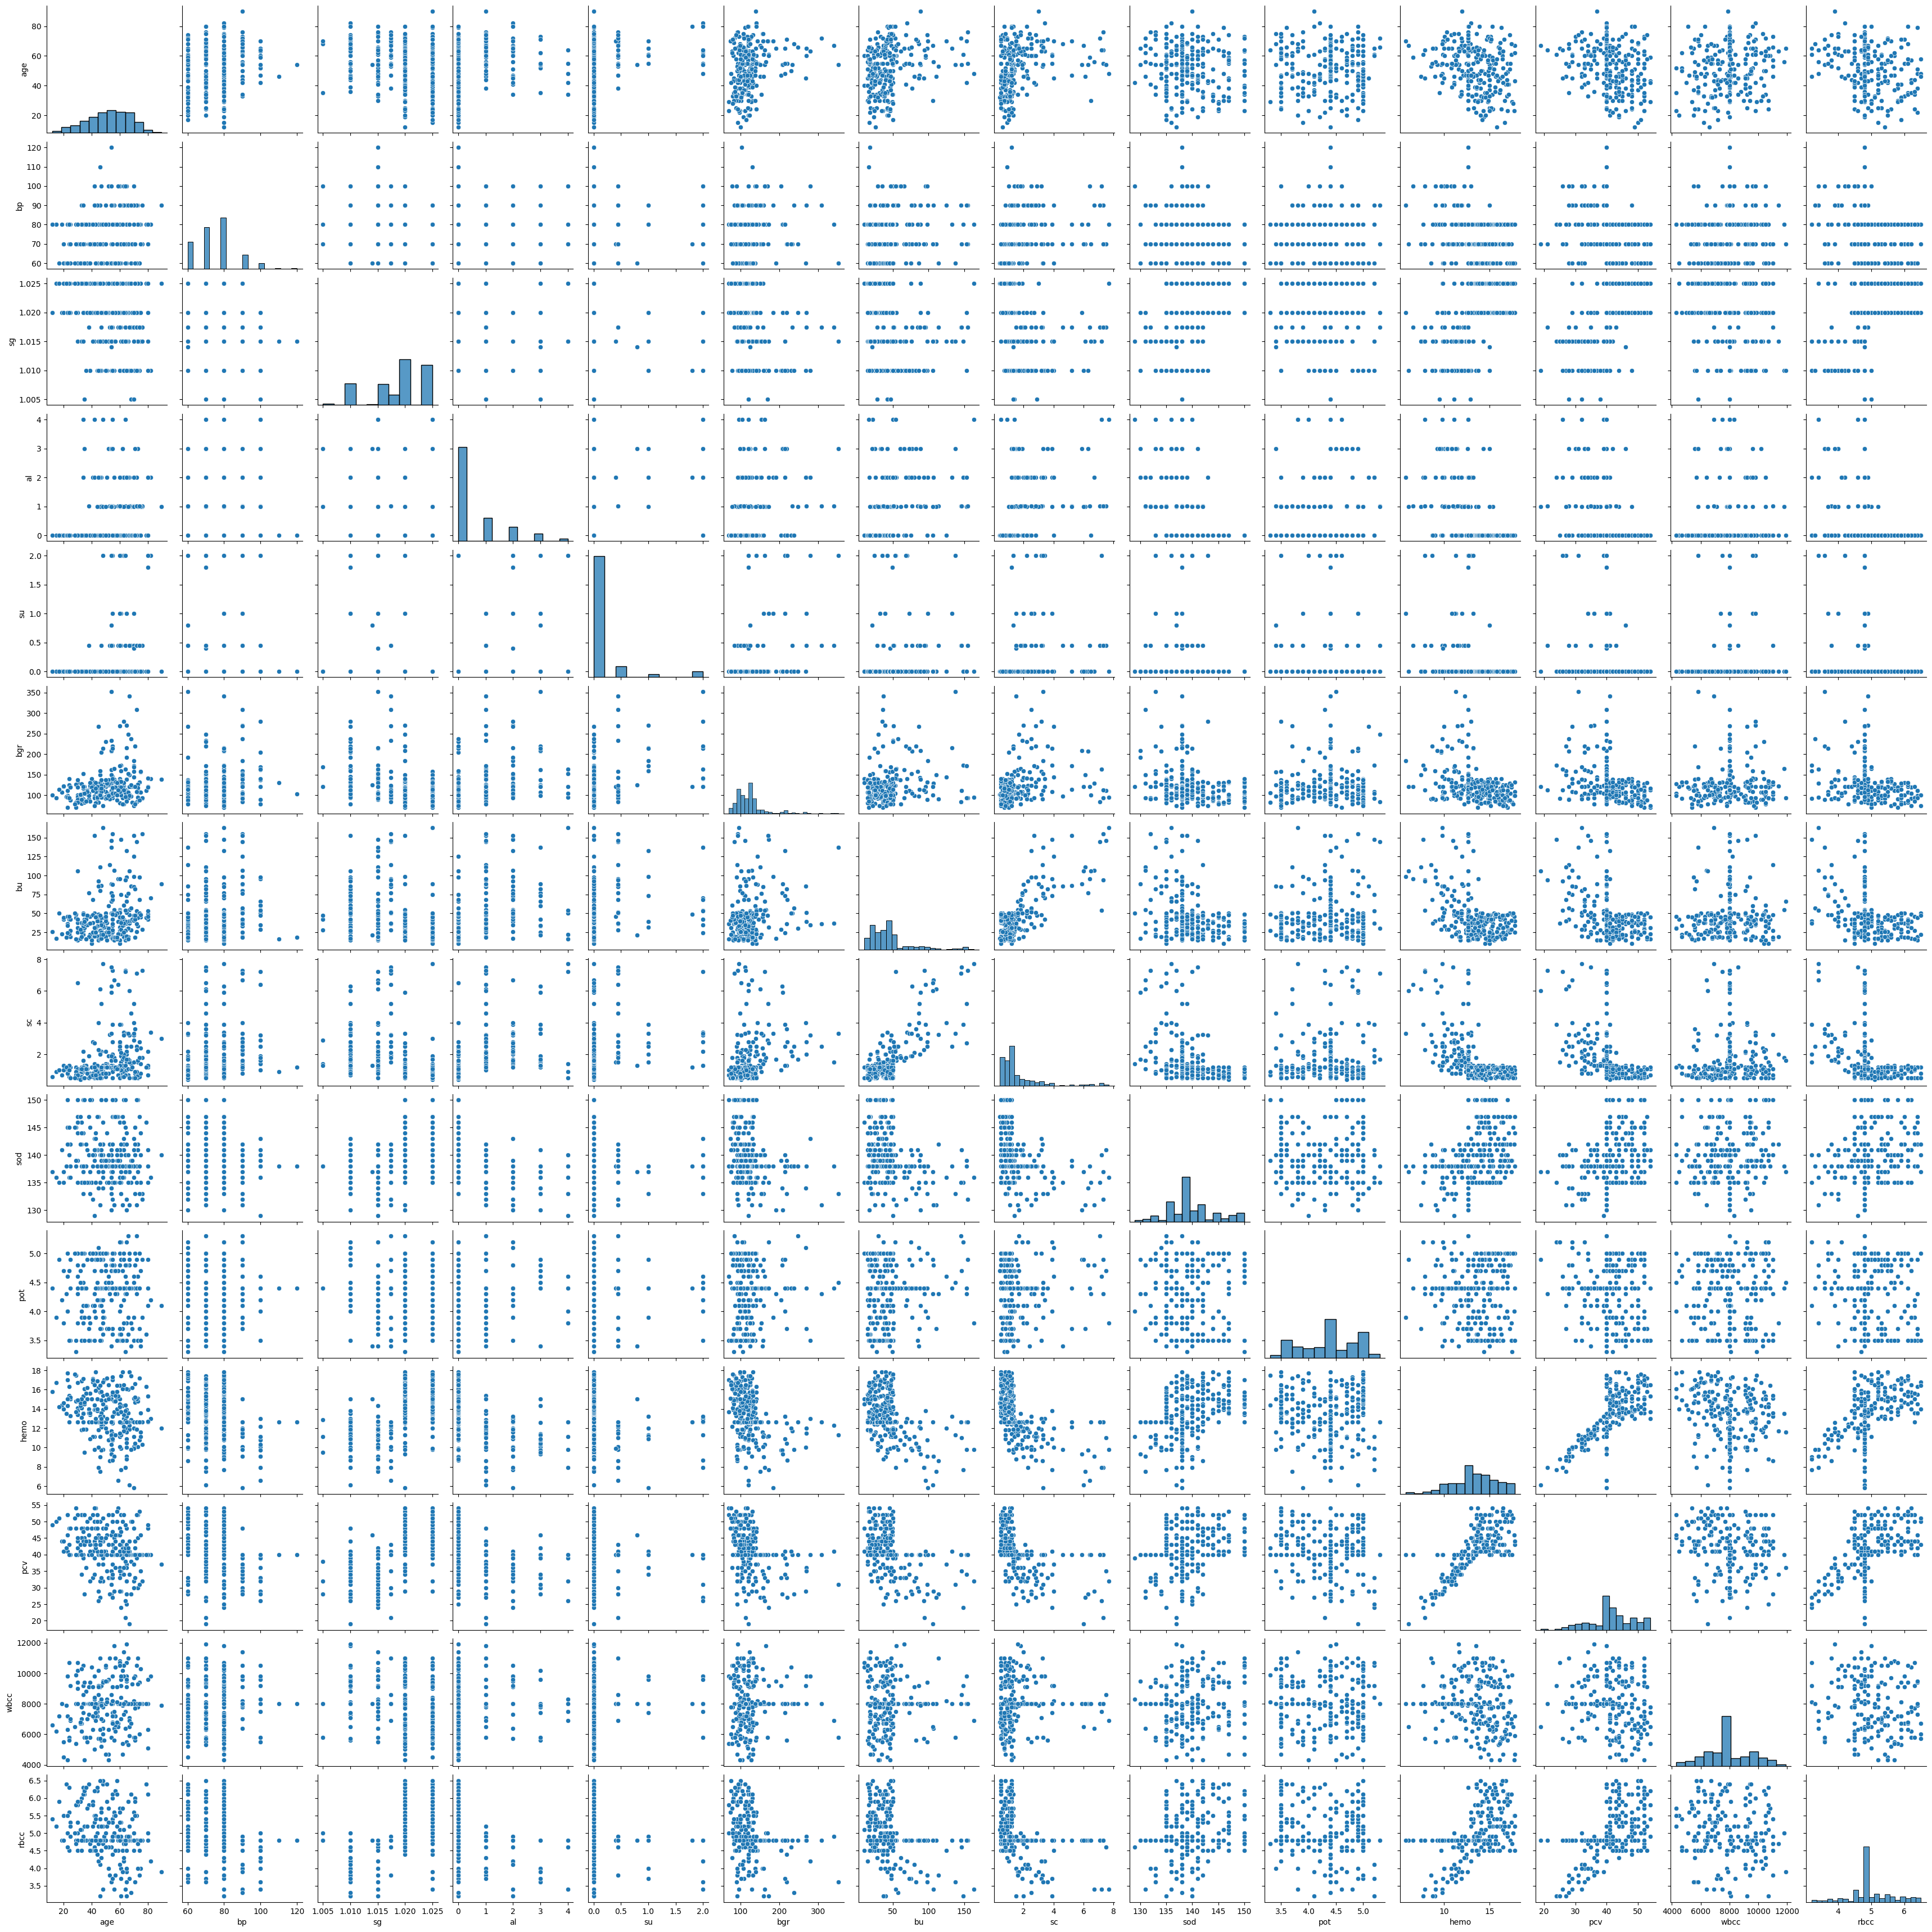

In [175]:
sns.pairplot(Similarity_Data_Sample)

# 7. PCA

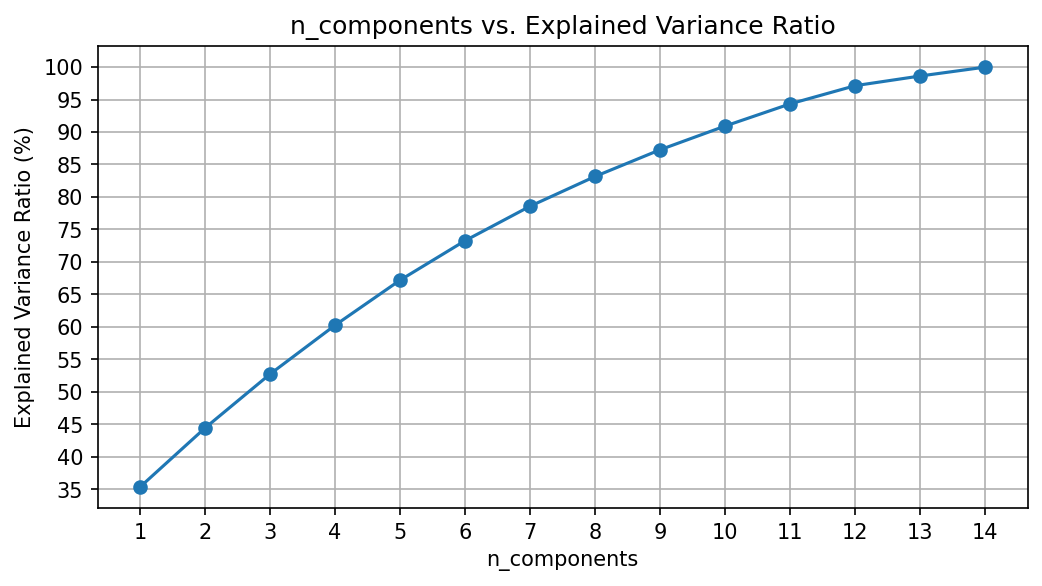

In [176]:
from sklearn.decomposition import PCA

scaler = StandardScaler()   # perlu distandarisasi karna sensitif sama angka besar, takut ada fitur yang bobotnya gede bgt ga adil nanti

numeric_cols = clean_data.select_dtypes(include=['number'])
scaled_array = scaler.fit_transform(numeric_cols)
numeric_cols = pd.DataFrame(scaled_array, columns=numeric_cols.columns, index=numeric_cols.index)

nums = np.arange(1, len(numeric_cols.columns) + 1)
var_ratio = []

for num in nums:
    pca_temp = PCA(n_components=num)
    pca_temp.fit(numeric_cols)
    var_ratio.append(np.sum(pca_temp.explained_variance_ratio_) * 100)

plt.figure(figsize=(8, 4), dpi=150)
plt.grid(True)
plt.xticks(ticks=nums)
plt.yticks(ticks=np.arange(0, 110, 5))
plt.plot(nums, var_ratio, marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained Variance Ratio (%)')
plt.title('n_components vs. Explained Variance Ratio')
plt.show()

In [177]:
pca_temp = PCA(n_components=9)
pca_temp.fit(numeric_cols)
pca_data = pca_temp.transform(numeric_cols)
# Column names
columns = ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'PCA8', 'PCA9']

# Creating DataFrame with specified data types
df_final = pd.DataFrame(pca_data, columns=columns)
df_final

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
0,0.717676,-0.272032,-0.364491,-0.207306,0.367614,0.343979,0.068009,-0.721962,0.069295
1,-1.445954,0.001728,-0.380936,-1.608084,0.532533,-0.478601,0.423266,-0.322982,-1.110457
2,-3.013932,0.632222,0.200047,-1.801712,0.472341,1.003743,-0.463257,-0.657621,0.062176
3,-2.257999,-0.818220,-0.434331,0.509210,-2.736081,-0.138536,0.005590,0.152740,-0.165616
4,-0.770796,-0.452575,-0.080999,-0.691497,-0.600901,-0.801113,-0.153270,-0.503930,-0.720399
...,...,...,...,...,...,...,...,...,...
255,1.575548,0.534380,0.799387,0.708262,1.200819,1.156419,0.511130,1.232274,-0.287278
256,3.260752,-0.497316,-0.858920,0.320324,-1.703141,0.320110,-0.552038,-0.623883,0.103875
257,2.289754,-1.403231,-0.748462,-0.938543,1.052134,0.125989,-1.440198,-0.467355,-0.277866
258,2.346091,-2.044351,0.332289,0.638264,0.891973,-1.145535,-1.251388,-0.978037,0.383481


# 8. Multiple Correspondence Analysis (For Object Data)

In [178]:
!pip install prince

In [179]:
object_cols = clean_data.select_dtypes(include=['object']).drop('class', axis=1)
object_cols

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane
0,abnormal,normal,notpresent,notpresent,yes,yes,no,good,no,no
1,normal,normal,notpresent,notpresent,no,no,no,good,no,no
2,normal,abnormal,present,notpresent,yes,yes,no,good,no,yes
3,abnormal,abnormal,notpresent,notpresent,yes,yes,yes,poor,yes,no
4,abnormal,normal,notpresent,notpresent,no,no,no,good,no,no
...,...,...,...,...,...,...,...,...,...,...
255,normal,normal,notpresent,notpresent,no,no,no,good,no,no
256,normal,normal,notpresent,notpresent,no,no,no,good,no,no
257,normal,normal,notpresent,notpresent,no,no,no,good,no,no
258,normal,normal,notpresent,notpresent,no,no,no,good,no,no


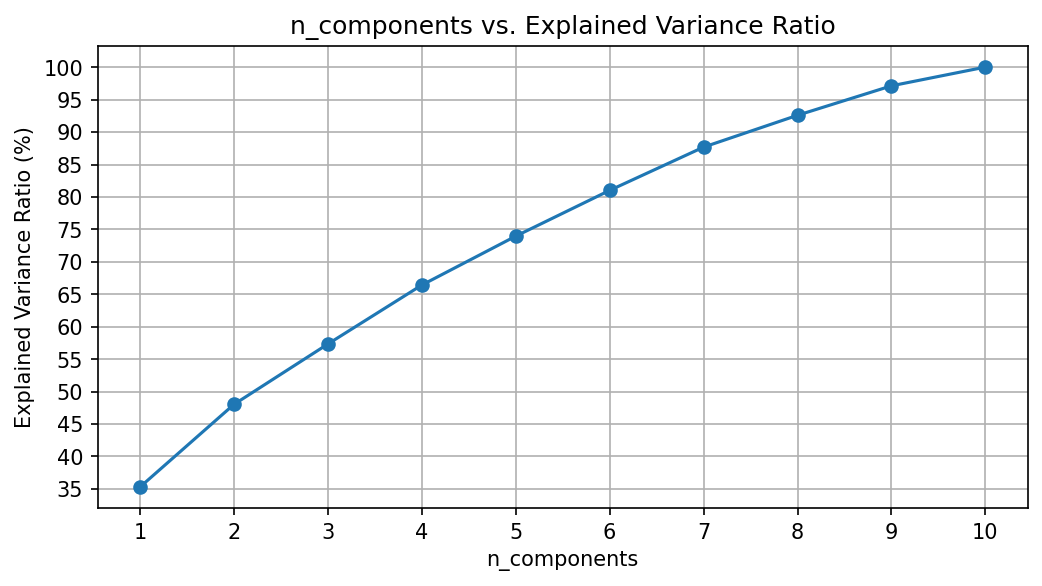

In [180]:
import prince

nums = np.arange(1, len(object_cols.columns) + 1)
var_ratio = []

for num in nums:
    mca_temp = prince.MCA(n_components=num)
    mca_temp.fit(object_cols)
    eigen_summary = mca_temp.eigenvalues_summary
    explained_variance = [float(val.strip('%')) for val in eigen_summary["% of variance"].values[:num]]
    var_ratio.append(sum(explained_variance))

plt.figure(figsize=(8, 4), dpi=150)
plt.grid(True)
plt.xticks(ticks=nums)
plt.yticks(ticks=np.arange(0, 110, 5))
plt.plot(nums, var_ratio, marker='o', linestyle='-')
plt.xlabel('n_components')
plt.ylabel('Explained Variance Ratio (%)')
plt.title('n_components vs. Explained Variance Ratio')
plt.show()

In [ ]:
mca_temp = prince.MCA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca_data = mca_temp.fit_transform(object_cols)
mca_data